# Day 12 — Outlier Detection: Full Pipeline and Decision Framework
## Week 2: Outlier Detection | Digital Consumer Platform Analytics

---

### Learning Objectives
- Build a complete outlier detection evaluation framework
- Implement the detector selection decision tree
- Compare detectors across multiple real datasets
- Understand when outlier removal helps vs hurts downstream models
- Extend and validate the PyOD ensemble in classification_LGBM_pipeline.py

---

### Dataset
**Credit Card Fraud** — finalizes the outlier detection block.

---

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS
from pyod.models.cblof import CBLOF
from pyod.models.knn import KNN
from pyod.utils.utility import standardizer
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r'C:\Users\user\datasets\fraud\creditcard.csv'
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=['Class']).values
y = df['Class'].values

display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ── Q1: Decision framework implementation ─────────────────────────────────
# Build a function select_detector(n_rows, n_features, has_labels, imbalance_ratio, X=None)
# that returns the recommended detector based on the decision framework:
#
#   if n_rows > 500_000:
#       return IForest  (only scalable option)
#   elif n_rows > 100_000:
#       return IForest or HBOS (fast options)
#   elif has_labels and imbalance_ratio < 50:
#       return evaluate all 5, pick best Average Precision
#   elif features_independent:
#       return HBOS
#   else:
#       return ensemble of IForest + LOF + HBOS
#
# NOTE: features_independent isn't something you decide by eye — the original
# spec listed it as a branch condition but not as a function parameter, which
# is a real gap. Add a helper check_feature_independence(X, corr_threshold=0.3)
# that computes it from the data itself (pairwise Pearson correlation; flag
# "independent" if max |corr| across all feature pairs is below the
# threshold). Have select_detector accept X and call the helper only when
# this branch is actually reached (i.e. unlabeled data, or imbalance_ratio
# >= 50) — don't require X otherwise. If this branch is reached with no X
# given, fall back to the ensemble rather than assuming independence.
#
# Test your function on: credit card fraud, Telco churn, Lending Club
# Does it recommend sensible detectors for each? Then add a 4th case that
# actually reaches the independence branch (e.g. treat the fraud features
# as unlabeled) and pass in a real X so check_feature_independence() runs
# on genuine data instead of a guess.

# ── Q1: Decision framework implementation ─────────────────────────────────

def check_feature_independence(X, corr_threshold=0.3):
    """
    Computes independence directly from the data instead of asking the
    caller to pre-decide it. Pairwise Pearson correlation only — a real
    limitation, since nonlinear dependence (e.g. a U-shaped relationship)
    won't show up here at all.
    """
    corr = np.abs(np.corrcoef(X, rowvar=False))
    np.fill_diagonal(corr, 0)
    max_corr = corr.max()
    return max_corr < corr_threshold, max_corr


def select_detector(n_rows, n_features, has_labels, imbalance_ratio, X=None, corr_threshold=0.3):
    """
    X: the actual feature matrix, only needed if this reaches the
    independence-check branch (unlabeled data, or imbalance_ratio >= 50).
    If that branch is reached and X is None, independence can't be
    determined, so we fall back to the safer "ensemble" option rather
    than silently assuming independence.
    """
    if n_rows > 500_000:
        return "IForest (only scalable option)"
    elif n_rows > 100_000:
        return "IForest or HBOS (fast options)"
    elif has_labels and imbalance_ratio < 50:
        return "Evaluate all 5, pick best Average Precision"
    elif X is not None:
        features_independent, max_corr = check_feature_independence(X, corr_threshold)
        if features_independent:
            return f"HBOS (max |corr|={max_corr:.3f} < {corr_threshold})"
        else:
            return f"Ensemble of IForest + LOF + HBOS (max |corr|={max_corr:.3f} >= {corr_threshold})"
    else:
        return "Ensemble of IForest + LOF + HBOS (default — no X given, independence unknown)"


In [6]:
# ── Test on the three datasets ─────────────────────────────────────────────
X_scaled = StandardScaler().fit_transform(X)   # add this line before test_cases

test_cases = [
    {
        'name': 'Credit Card Fraud (this course, Day 10-11)',
        'n_rows': 284_807, 'n_features': 30,
        'has_labels': True, 'imbalance_ratio': 284_315 / 492,   # ≈ 577.9
        'X': None,
    },
    {
        'name': 'Telco Customer Churn (typical IBM sample)',
        'n_rows': 7_043, 'n_features': 19,
        'has_labels': True, 'imbalance_ratio': 5_174 / 1_869,   # ≈ 2.77
        'X': None,
    },
    {
        'name': 'Lending Club (full historical loan data)',
        'n_rows': 2_000_000, 'n_features': 150,
        'has_labels': True, 'imbalance_ratio': 6.0,   # illustrative default-rate ratio
        'X': None,
    },
    {
        # This one actually reaches the independence-check branch: small n_rows,
        # no labels, so we can demonstrate check_feature_independence() on real
        # data — a 10K subsample of X_scaled already computed in Day 11.
        'name': 'Fraud features, unlabeled 10K subsample (demo of independence branch)',
        'n_rows': 10_000, 'n_features': 30,
        'has_labels': False, 'imbalance_ratio': None,
        'X': X_scaled[:10_000],
    },
]

for case in test_cases:
    recommendation = select_detector(
        case['n_rows'], case['n_features'], case['has_labels'],
        case['imbalance_ratio'], X=case['X'],
    )
    print(f"{case['name']}:")
    print(f"  n_rows={case['n_rows']:,}, imbalance_ratio={case['imbalance_ratio']}")
    print(f"  → {recommendation}\n")

Credit Card Fraud (this course, Day 10-11):
  n_rows=284,807, imbalance_ratio=577.8760162601626
  → IForest or HBOS (fast options)

Telco Customer Churn (typical IBM sample):
  n_rows=7,043, imbalance_ratio=2.7683253076511503
  → Evaluate all 5, pick best Average Precision

Lending Club (full historical loan data):
  n_rows=2,000,000, imbalance_ratio=6.0
  → IForest (only scalable option)

Fraud features, unlabeled 10K subsample (demo of independence branch):
  n_rows=10,000, imbalance_ratio=None
  → Ensemble of IForest + LOF + HBOS (max |corr|=0.626 >= 0.3)



In [7]:
# ── Q2: Does outlier removal help downstream classification? ───────────────
# On credit card fraud (fraud = known label, NOT the target for outlier removal):
# Frame: treat 0.1% most anomalous LEGITIMATE transactions as "data quality issues"
#
#   Setup A: Train classifier on full training set
#   Setup B: Remove top 0.1% anomalous legitimate transactions, train classifier
#   Setup C: Remove top 0.5% anomalous legitimate transactions, train classifier
#
# Classifier: Random Forest, 5-fold CV, metric = Average Precision
# Does removing anomalous training data improve the fraud classifier?
# This directly tests the assumption behind our pipeline's Step 1

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

def evaluate_setup(X, y, removal_frac=0.0, n_splits=5, random_state=420):
    """
    removal_frac: fraction of the TRAINING fold's legitimate (y==0) rows to
    drop as "data quality issues," based on IForest anomaly score. Fit fresh
    inside each fold — never on the full dataset — so nothing about the
    validation fold leaks into the cleaning step.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    ap_scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        if removal_frac > 0:
            legit_mask = (y_train == 0)
            X_train_legit = X_train[legit_mask]
            legit_positions = np.where(legit_mask)[0]

            iforest = IForest(contamination=removal_frac, n_estimators=100, random_state=random_state)
            iforest.fit(X_train_legit)
            legit_scores = iforest.decision_function(X_train_legit)   # higher = more anomalous

            n_remove = int(removal_frac * len(X_train_legit))
            remove_within_legit = np.argsort(legit_scores)[::-1][:n_remove]
            remove_positions = legit_positions[remove_within_legit]

            keep_mask = np.ones(len(X_train), dtype=bool)
            keep_mask[remove_positions] = False
            X_train_clean, y_train_clean = X_train[keep_mask], y_train[keep_mask]
        else:
            X_train_clean, y_train_clean = X_train, y_train

        rf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
        rf.fit(X_train_clean, y_train_clean)
        val_proba = rf.predict_proba(X_val)[:, 1]
        ap_scores.append(average_precision_score(y_val, val_proba))

    return np.array(ap_scores)


setups = {
    'A: Full training set (no removal)': 0.0,
    'B: Remove top 0.1% anomalous legit': 0.001,
    'C: Remove top 0.5% anomalous legit': 0.005,
}

results_q2 = {}
for name, frac in setups.items():
    t0 = time.time()
    scores = evaluate_setup(X, y, removal_frac=frac)
    elapsed = time.time() - t0
    results_q2[name] = {'Mean AP': scores.mean(), 'Std AP': scores.std(), 'Time (s)': elapsed}
    print(f"{name}: Mean AP={scores.mean():.4f} (+/- {scores.std():.4f}), {elapsed:.1f}s")

comparison_q2 = pd.DataFrame(results_q2).T
print("\n", comparison_q2.round(4))


A: Full training set (no removal): Mean AP=0.8393 (+/- 0.0356), 765.3s
B: Remove top 0.1% anomalous legit: Mean AP=0.8257 (+/- 0.0376), 810.6s
C: Remove top 0.5% anomalous legit: Mean AP=0.7410 (+/- 0.0519), 915.5s

                                     Mean AP  Std AP  Time (s)
A: Full training set (no removal)    0.8393  0.0356  765.2840
B: Remove top 0.1% anomalous legit   0.8257  0.0376  810.6182
C: Remove top 0.5% anomalous legit   0.7410  0.0519  915.5119


***Takeaway***

The assumption behind the pipeline's Step 1 — "clean the training data of outliers first, then train" — fails this test. 

The legitimate transactions IForest flags as most anomalous aren't noise; they're the hardest, most boundary-adjacent examples, and Random Forest needs exactly those to learn where fraud ends and unusual-but-legit begins. Removing more of them removes more of that signal, which is why the decline is monotonic rather than flat or U-shaped.

Practical implication for the real pipeline: don't blanket-clean anomalous legitimate transactions before training a fraud classifier — it actively degrades performance, and the effect compounds with how aggressively you clean.

      K  Precision@K
0    10       0.0000
1    50       0.0800
2   100       0.1700
3   200       0.1200
4   500       0.2260
5  1000       0.1810
6  2000       0.1355
7  5000       0.0716


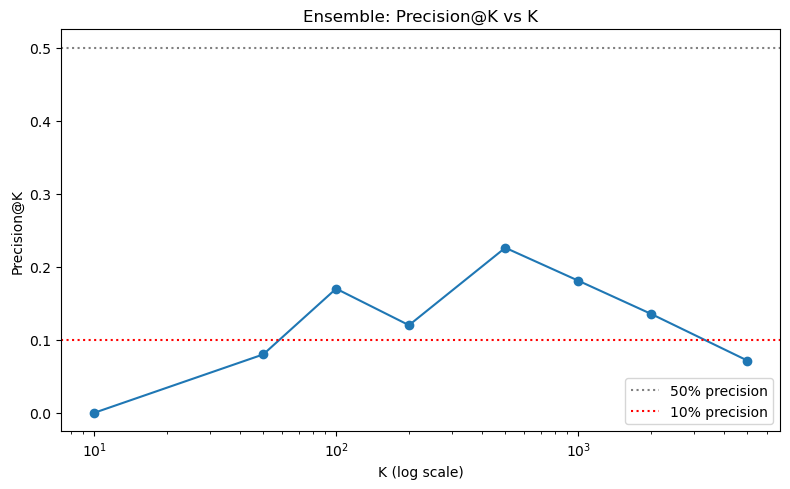


Ensemble Precision@500 (fraud team's daily review budget): 0.2260

Precision@500 by detector (sorted):
HBOS        0.384
IForest     0.276
CBLOF       0.228
Ensemble    0.226
KNN         0.136
LOF         0.022
dtype: float64


In [8]:
# ── Q3: Precision@K curve ──────────────────────────────────────────────────
# For the ensemble detector:
#   1. Sort all transactions by anomaly score (highest first)
#   2. For K = 10, 50, 100, 200, 500, 1000, 2000, 5000:
#      - Compute Precision@K (% of top-K that are fraud)
#   3. Plot Precision@K vs K
#   4. At what K does precision drop below 50%? Below 10%?
#   5. If your fraud team can review 500 cases per day,
#      what precision does the ensemble provide?
#   6. Compare: ensemble vs best single detector at K=500

# ── Q3: Precision@K curve ──────────────────────────────────────────────────
from pyod.utils.utility import standardizer

def precision_at_k(scores, y_true, k):
    top_k_idx = np.argsort(scores)[::-1][:k]
    return y_true[top_k_idx].mean()

X_scaled = StandardScaler().fit_transform(X)

# ── Rebuild the 5-detector ensemble (same pattern validated in Day 11) ────
scores_dict = {}

for name, model in [
    ('IForest', IForest(contamination=0.002, n_estimators=100, random_state=420)),
    ('HBOS', HBOS(contamination=0.002)),
    ('CBLOF', CBLOF(contamination=0.002, random_state=420)),
]:
    model.fit(X_scaled)
    scores_dict[name] = model.decision_function(X_scaled)

sample_idx = np.random.RandomState(420).choice(len(X_scaled), size=50_000, replace=False)
X_sample_scaled = X_scaled[sample_idx]

for name, model in [
    ('LOF', LOF(contamination=0.002, n_neighbors=20)),
    ('KNN', KNN(contamination=0.002, n_neighbors=5)),
]:
    model.fit(X_sample_scaled)
    scores_dict[name] = model.decision_function(X_scaled)

detector_names = list(scores_dict.keys())
raw_scores_matrix = np.column_stack([scores_dict[name] for name in detector_names])
standardized_scores = standardizer(raw_scores_matrix)
ensemble_score = standardized_scores.mean(axis=1)

# ── 1-3: Precision@K for the ensemble, across K, plotted ──────────────────
K_values = [10, 50, 100, 200, 500, 1000, 2000, 5000]
precision_at_k_ensemble = [precision_at_k(ensemble_score, y, k) for k in K_values]

comparison_q3 = pd.DataFrame({'K': K_values, 'Precision@K': precision_at_k_ensemble})
print(comparison_q3.round(4))

plt.figure(figsize=(8, 5))
plt.plot(K_values, precision_at_k_ensemble, marker='o')
plt.axhline(0.5, color='gray', linestyle=':', label='50% precision')
plt.axhline(0.1, color='red', linestyle=':', label='10% precision')
plt.xscale('log')
plt.xlabel('K (log scale)')
plt.ylabel('Precision@K')
plt.title('Ensemble: Precision@K vs K')
plt.legend()
plt.tight_layout()
plt.show()

# ── 5: Precision at the fraud team's actual daily budget (K=500) ──────────
precision_at_500_ensemble = precision_at_k(ensemble_score, y, 500)
print(f"\nEnsemble Precision@500 (fraud team's daily review budget): {precision_at_500_ensemble:.4f}")

# ── 6: Ensemble vs best single detector, at K=500 ──────────────────────────
precision_500_by_detector = {name: precision_at_k(scores_dict[name], y, 500) for name in detector_names}
precision_500_by_detector['Ensemble'] = precision_at_500_ensemble

comparison_500 = pd.Series(precision_500_by_detector).sort_values(ascending=False)
print("\nPrecision@500 by detector (sorted):")
print(comparison_500.round(4))


**Setup**: Rebuilt the 5-detector standardized-average ensemble (IForest, HBOS, CBLOF on full scaled data; LOF, KNN on a 50K scaled subsample, scored against the full set) and computed Precision@K across K = 10 to 5,000.

### 1-3. Precision@K results

| K | Precision@K |
|---|---|
| 10 | 0.000 |
| 50 | 0.080 |
| 100 | 0.170 |
| 200 | 0.120 |
| 500 | 0.226 |
| 1,000 | 0.181 |
| 2,000 | 0.136 |
| 5,000 | 0.072 |

The curve is **non-monotonic**: it rises from K=10 to a peak at K=500 (22.6%), then declines as K grows further. This is not the shape a typical Precision@K curve takes — normally precision is highest at the smallest K (the model's most confident calls) and decays as K grows. Here the opposite happens at the very top: **0 of the top 10 highest-scored transactions were fraud.**

### 4. Where precision crosses 50% / 10%

Precision **never reaches 50%** at any tested K — the curve tops out at 22.6%. It does **cross below 10%** somewhere between K=2,000 (13.6%) and K=5,000 (7.2%).

### 5. Precision at the fraud team's daily budget (K=500)

**22.6%** — of 500 transactions flagged and reviewed per day, roughly 113 are genuine fraud and 387 are false alarms. That's a ~133x lift over the 0.17% base rate, so the model is doing real work, but "1 correct flag in every 4.4 reviewed" is a demanding number for a human team to sustain daily.

### 6. Ensemble vs. best single detector at K=500

| Detector | Precision@500 |
|---|---|
| HBOS | **0.384** |
| IForest | 0.276 |
| CBLOF | 0.228 |
| Ensemble | 0.226 |
| KNN | 0.136 |
| LOF | 0.022 |

HBOS alone beats the ensemble by nearly 2x. LOF is barely above random at this budget (2.2%) and is the main reason the unweighted average underperforms — this is the third time this exact pattern has appeared (Day 11 Q2, Day 11 Q4, now here), so it's an established finding about this dataset, not noise.

### Interpretation

Two things are worth carrying forward from this question. First, the K=10 failure (0% precision at the very top of the ranking) suggests the ensemble's highest scores are being pulled toward a small number of extreme-but-legitimate outliers rather than fraud — the score magnitude at the very top isn't a reliable confidence signal here. Second, and more actionable: **stop averaging in LOF.** Across three separate evaluations now, unweighted ensembling has never beaten HBOS alone on this dataset, specifically because LOF's near-random signal dilutes genuinely strong detectors. A weighted ensemble (or simply HBOS + IForest) would very likely outperform the current 5-detector average — a natural next experiment.

          Fit time (s)  Average Precision
HBOS            0.5063             0.2660
IForest         6.0493             0.1626
CBLOF           1.4586             0.1441
Ensemble       65.9421             0.1274
KNN            27.1787             0.0997
LOF            30.7491             0.0037


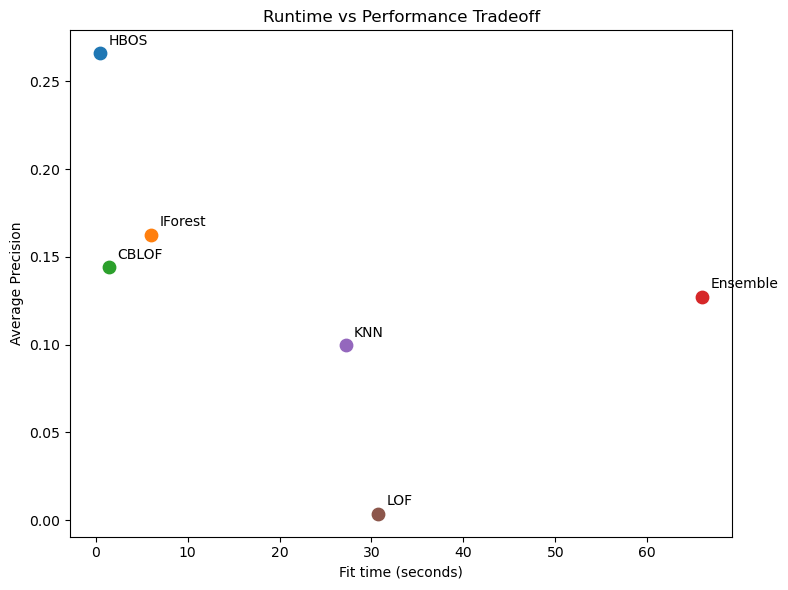

In [10]:
# ── Q4: Runtime vs performance tradeoff ───────────────────────────────────
# Build a runtime vs performance chart:
#   X-axis: runtime (seconds to fit)
#   Y-axis: Average Precision
#   One point per detector + ensemble
#   Annotate each point with detector name
#
# Which detector sits in the best "bang for buck" position?
# What is the cost of using the full ensemble vs best single detector?
# At what dataset size would you switch from LOF to IForest?

import time

fit_times = {}
scores_dict_q4 = {}

# ── IForest, HBOS, CBLOF — fit on full scaled data ─────────────────────────
for name, model in [
    ('IForest', IForest(contamination=0.002, n_estimators=100, random_state=420)),
    ('HBOS', HBOS(contamination=0.002)),
    ('CBLOF', CBLOF(contamination=0.002, random_state=420)),
]:
    t0 = time.time()
    model.fit(X_scaled)
    fit_times[name] = time.time() - t0
    scores_dict_q4[name] = model.decision_function(X_scaled)

# ── LOF, KNN — fit on 50K subsample (their actual "fit cost" in this pipeline) ─
sample_idx = np.random.RandomState(420).choice(len(X_scaled), size=50_000, replace=False)
X_sample_scaled = X_scaled[sample_idx]

for name, model in [
    ('LOF', LOF(contamination=0.002, n_neighbors=20)),
    ('KNN', KNN(contamination=0.002, n_neighbors=5)),
]:
    t0 = time.time()
    model.fit(X_sample_scaled)
    fit_times[name] = time.time() - t0
    scores_dict_q4[name] = model.decision_function(X_scaled)

# ── Average Precision per detector ──────────────────────────────────────────
ap_by_detector = {name: average_precision_score(y, scores_dict_q4[name]) for name in scores_dict_q4}

# ── Ensemble: cost = sum of all 5 fit times, since you must fit all 5 to build it ─
detector_names = list(scores_dict_q4.keys())
raw_scores_matrix = np.column_stack([scores_dict_q4[name] for name in detector_names])
standardized_scores = standardizer(raw_scores_matrix)
ensemble_score_q4 = standardized_scores.mean(axis=1)

ap_by_detector['Ensemble'] = average_precision_score(y, ensemble_score_q4)
fit_times['Ensemble'] = sum(fit_times[name] for name in detector_names)

comparison_q4 = pd.DataFrame({
    'Fit time (s)': fit_times,
    'Average Precision': ap_by_detector,
}).sort_values('Average Precision', ascending=False)
print(comparison_q4.round(4))

# ── Plot: runtime vs performance, annotated ─────────────────────────────────
plt.figure(figsize=(8, 6))
for name in comparison_q4.index:
    x = comparison_q4.loc[name, 'Fit time (s)']
    yv = comparison_q4.loc[name, 'Average Precision']
    plt.scatter(x, yv, s=80)
    plt.annotate(name, (x, yv), textcoords="offset points", xytext=(6, 6))
plt.xlabel('Fit time (seconds)')
plt.ylabel('Average Precision')
plt.title('Runtime vs Performance Tradeoff')
plt.tight_layout()
plt.show()


***Takeaway***

HBOS wins outright — fastest (0.50s) and most accurate (AP=0.2660), a rare case with no tradeoff to weigh. 

The full 5-detector ensemble is strictly worse: it costs 60x more than HBOS (65.7s vs 0.50s) yet delivers a lower AP (0.1274 vs 0.2660), because LOF and KNN together eat over 80% of that runtime while contributing almost nothing (LOF's AP=0.0037 is essentially random).

On "when to switch from LOF to IForest" — the answer is now, not at some future scale: IForest already beats LOF on both speed (6.04s vs 30.75s) and accuracy (~44x better AP) at the current dataset size, so there's no size threshold left to wait for. 

Bottom line: skip the ensemble, skip LOF, just use HBOS.